### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [1]:
cd /content/drive/MyDrive/emg2qwerty

/content/drive/MyDrive/emg2qwerty


### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [3]:
!pip install -r requirements.txt

     / 553.6 kB 1.9 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could 

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [2]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  # --multirun

[2026-03-11 03:02:24,471][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [12]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="/content/drive/MyDrive/emg2qwerty/logs/2026-03-08/18-53-50/checkpoints/epoch-98-step-11880.ckpt" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy \
  hydra.launcher.mem_gb=64 \
  # --multirun

[2026-03-10 02:01:49,431][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

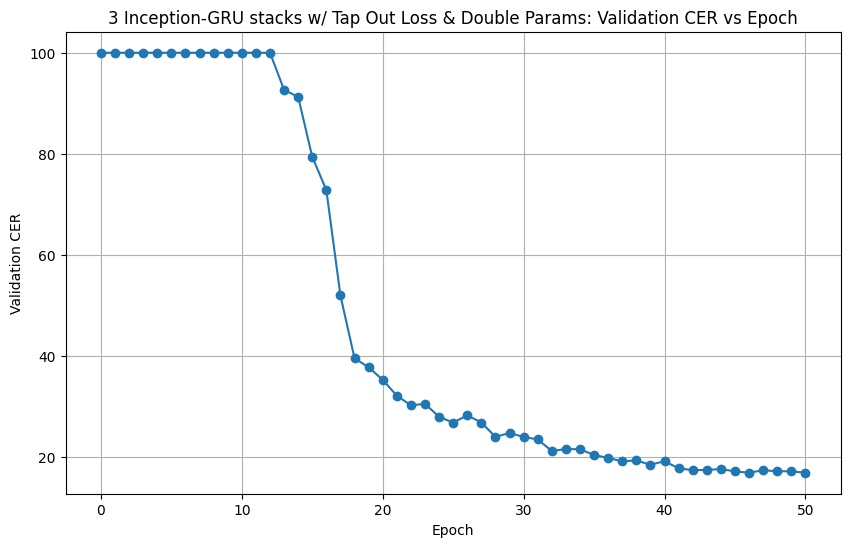

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import math

#2 stacks 2026-03-09/20-13-11
# 3 stacks: 2026-03-08/23-56-03

#256 hidden: 2026-03-10/00-41-22
#more reg: 2026-03-10/01-30-15
#just slightly more: 2026-03-10/02-02-57
df = pd.read_csv("/content/drive/MyDrive/emg2qwerty/logs/2026-03-10/00-41-22/csv_logs/version_0/metrics.csv")

cer_df = df[["epoch", "val/CER"]].dropna()
plt.figure(figsize=(10, 6))
plt.plot(cer_df["epoch"], cer_df["val/CER"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation CER")
# plt.yscale('log')
plt.title("3 Inception-GRU stacks w/ Tap Out Loss & Double Params: Validation CER vs Epoch")
plt.grid(True)

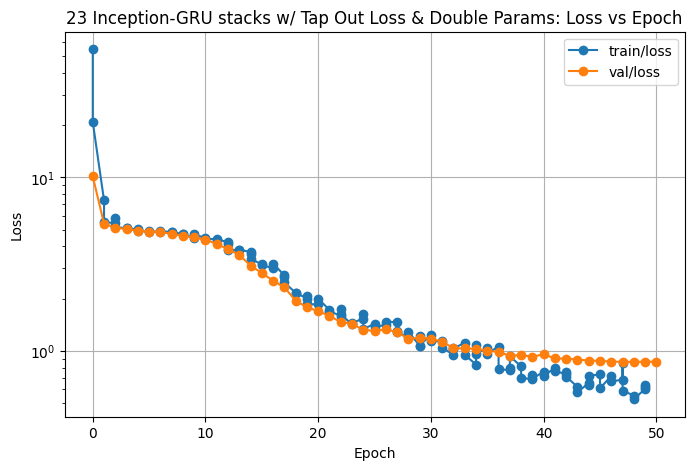

In [19]:

plt.figure(figsize=(8, 5))

if "train/loss" in df.columns:
    train_loss = df[["epoch", "train/loss"]].dropna()
    plt.plot(train_loss["epoch"], train_loss["train/loss"], marker="o", label="train/loss")

if "val/loss" in df.columns:
    val_loss = df[["epoch", "val/loss"]].dropna()
    plt.plot(val_loss["epoch"], val_loss["val/loss"], marker="o", label="val/loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.title("23 Inception-GRU stacks w/ Tap Out Loss & Double Params: Loss vs Epoch")
plt.legend()
plt.grid(True)